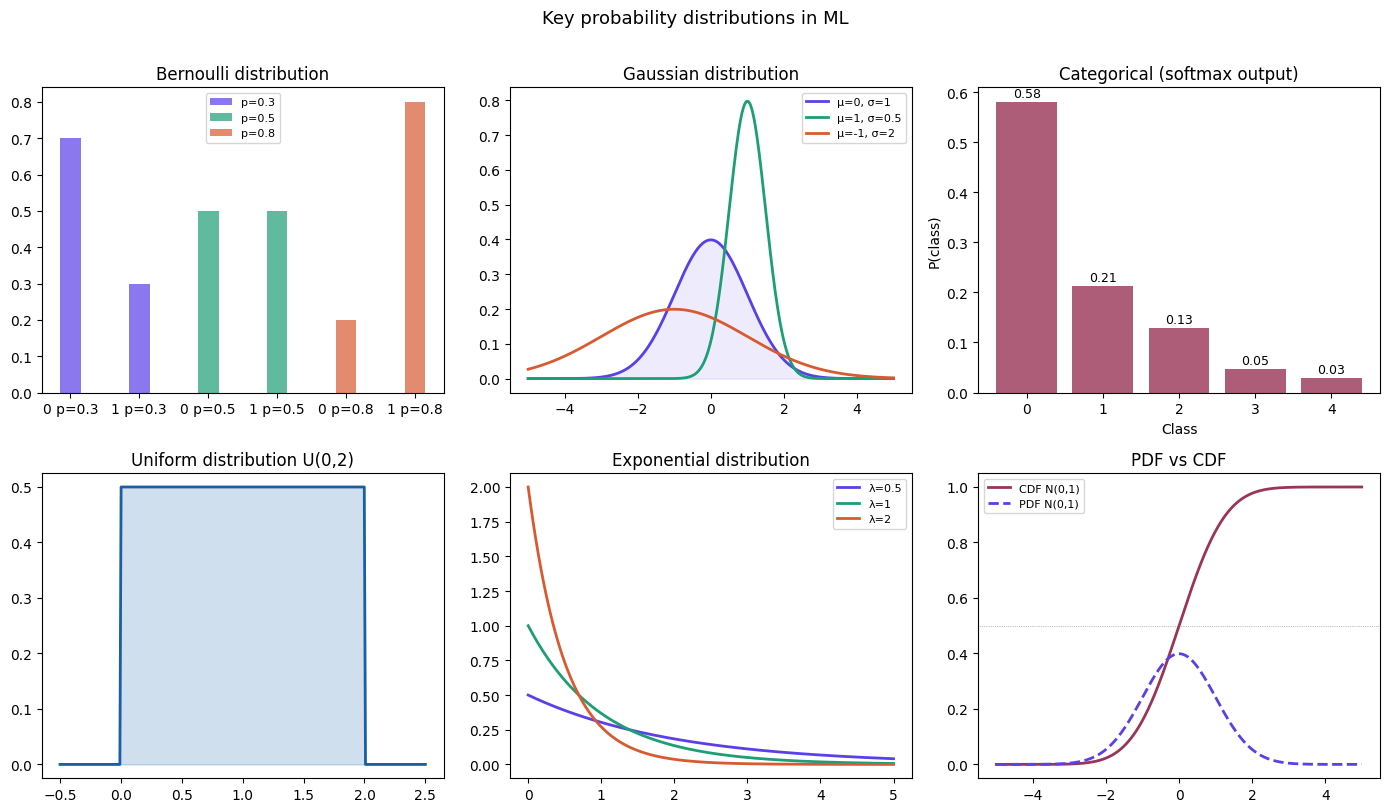

Prior P(disease)            = 0.01
Posterior P(disease|+test)  = 0.0876 (8.8%)


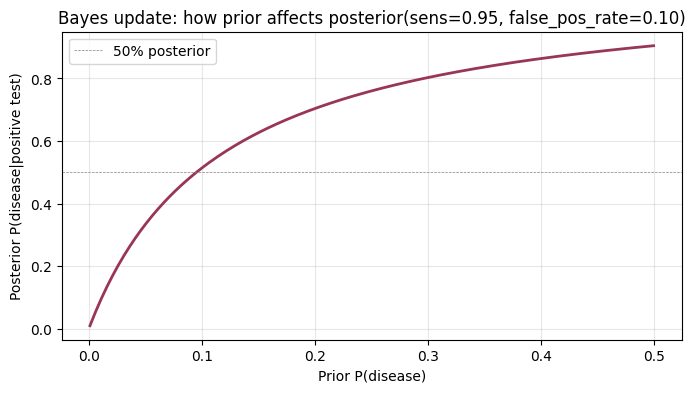

Naive Bayes spam classifier:
Test email: ['free', 'meeting', 'prize']
Log P(spam|email) = -8.898
Log P(ham|email)  = -9.591
Prediction: SPAM
P(spam|email) = 0.667
Save as day11_probability.ipynb and push to GitHub.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# ── 1. Visualise key distributions ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Bernoulli
p_vals = [0.3, 0.5, 0.8]
ax = axes[0,0]
for p, c in zip(p_vals, ['#5B3FE8','#1D9E75','#D85A30']):
    ax.bar([f'0 p={p}', f'1 p={p}'], [1-p, p], alpha=0.7, color=c,
           label=f'p={p}', width=0.3, bottom=0)
ax.set_title('Bernoulli distribution'); ax.legend(fontsize=8)

# Gaussian
x = np.linspace(-5, 5, 300)
ax = axes[0,1]
for mu, sigma, c in [(0,1,'#5B3FE8'),(1,0.5,'#1D9E75'),(-1,2,'#D85A30')]:
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color=c, lw=2,
            label=f'μ={mu}, σ={sigma}')
ax.set_title('Gaussian distribution'); ax.legend(fontsize=8)
ax.fill_between(x, stats.norm.pdf(x,0,1), alpha=0.1, color='#5B3FE8')

# Categorical (softmax outputs)
ax = axes[0,2]
logits = np.array([2.0, 1.0, 0.5, -0.5, -1.0])
probs  = np.exp(logits) / np.exp(logits).sum()
ax.bar(range(5), probs, color='#993556', alpha=0.8)
ax.set_title('Categorical (softmax output)')
ax.set_xlabel('Class'); ax.set_ylabel('P(class)')
for i,p in enumerate(probs):
    ax.text(i, p+0.01, f'{p:.2f}', ha='center', fontsize=9)

# Uniform
ax = axes[1,0]
x_u = np.linspace(-0.5, 2.5, 300)
ax.plot(x_u, stats.uniform.pdf(x_u, 0, 2), color='#185FA5', lw=2)
ax.fill_between(x_u, stats.uniform.pdf(x_u,0,2), alpha=0.2, color='#185FA5')
ax.set_title('Uniform distribution U(0,2)')

# Exponential
ax = axes[1,1]
x_e = np.linspace(0, 5, 300)
for lam, c in [(0.5,'#5B3FE8'),(1,'#1D9E75'),(2,'#D85A30')]:
    ax.plot(x_e, stats.expon.pdf(x_e, scale=1/lam), color=c, lw=2, label=f'λ={lam}')
ax.set_title('Exponential distribution'); ax.legend(fontsize=8)

# Gaussian CDF
ax = axes[1,2]
ax.plot(x, stats.norm.cdf(x,0,1), color='#993556', lw=2, label='CDF N(0,1)')
ax.plot(x, stats.norm.pdf(x,0,1), color='#5B3FE8', lw=2, ls='--', label='PDF N(0,1)')
ax.axhline(0.5, color='gray', lw=0.5, ls=':')
ax.set_title('PDF vs CDF'); ax.legend(fontsize=8)

plt.suptitle('Key probability distributions in ML', y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

# ── 2. Bayes theorem — medical test ──────────────────────
def bayes_update(prior, likelihood_pos, likelihood_neg):
    """Compute posterior given prior and likelihoods."""
    p_pos = likelihood_pos*prior + likelihood_neg*(1-prior)
    posterior = likelihood_pos * prior / p_pos
    return posterior

prior       = 0.01   # P(disease)
sens        = 0.95   # P(positive|disease)
false_pos   = 0.10   # P(positive|healthy)

posterior = bayes_update(prior, sens, false_pos)
print(f"Prior P(disease)            = {prior:.2f}")
print(f"Posterior P(disease|+test)  = {posterior:.4f} ({posterior*100:.1f}%)")

# Visualise: how posterior changes with prior
priors = np.linspace(0.001, 0.5, 200)
posteriors = [bayes_update(p, sens, false_pos) for p in priors]
plt.figure(figsize=(8,4))
plt.plot(priors, posteriors, color='#993556', lw=2)
plt.axhline(0.5, color='gray', lw=0.5, ls='--', label='50% posterior')
plt.xlabel('Prior P(disease)'); plt.ylabel('Posterior P(disease|positive test)')
plt.title('Bayes update: how prior affects posterior(sens=0.95, false_pos_rate=0.10)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

# ── 3. Naive Bayes spam classifier from scratch ───────────
# Training data: (label, words_in_email)
emails = [
    (1, ['free', 'money', 'win', 'prize']),
    (1, ['free', 'offer', 'click', 'now']),
    (1, ['money', 'win', 'now', 'urgent']),
    (0, ['meeting', 'project', 'report', 'deadline']),
    (0, ['lunch', 'meeting', 'tomorrow', 'report']),
    (0, ['project', 'update', 'team', 'deadline']),
]
test_email = ['free', 'meeting', 'prize']

# Count statistics
from collections import Counter, defaultdict
spam   = [e for label,e in emails if label==1]
ham    = [e for label,e in emails if label==0]
p_spam = len(spam)/len(emails)
p_ham  = 1 - p_spam

# Word counts with Laplace smoothing
all_words = set(w for _,e in emails for w in e)
spam_words = Counter(w for e in spam for w in e)
ham_words  = Counter(w for e in ham  for w in e)
V = len(all_words)

def p_word_given_class(word, word_counts, n_docs, alpha=1):
    """P(word|class) with Laplace smoothing."""
    return (word_counts[word] + alpha) / (sum(word_counts.values()) + alpha*V)

# Classify test email using log probabilities (avoid underflow)
log_p_spam = np.log(p_spam)
log_p_ham  = np.log(p_ham)
for word in test_email:
    log_p_spam += np.log(p_word_given_class(word, spam_words, len(spam)))
    log_p_ham  += np.log(p_word_given_class(word, ham_words,  len(ham)))

print(f"Naive Bayes spam classifier:")
print(f"Test email: {test_email}")
print(f"Log P(spam|email) = {log_p_spam:.3f}")
print(f"Log P(ham|email)  = {log_p_ham:.3f}")
print(f"Prediction: {'SPAM' if log_p_spam > log_p_ham else 'HAM'}")

# Convert to probabilities
prob_spam = np.exp(log_p_spam)/(np.exp(log_p_spam)+np.exp(log_p_ham))
print(f"P(spam|email) = {prob_spam:.3f}")
print("Save as day11_probability.ipynb and push to GitHub.")